In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt

from datasets import Dataset

In [10]:
tokenizers = ("SentencePieceBPE")
vocab_sizes = [(2 ** 8) * (2 ** i) for i in range(2, 10, 2)]

data = {}
for v in vocab_sizes:
    path = Path(f"./output/datasets/tokenized/{v}")
    if not path.exists():
        continue
    print(f"Loading {v}")
    tokenized_dataset = Dataset.load_from_disk(path, keep_in_memory=True)
    data[v] = [len(d["input_ids"]) for d in tokenized_dataset]

Loading 256
Loading 512
Loading 1024
Loading 2048
Loading 4096
Loading 8192
Loading 16384
Loading 32768
Loading 65536
Loading 131072
Loading 262144
Loading 524288
Loading 1048576


In [12]:
import json

with open("sequence-lengths.json", "w") as handle:
    json.dump(data, handle, indent=4)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fc1969e5cf0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fc1969e6230>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fc1969e5a50>,
 'medians': [<matplotlib.lines.Line2D at 0x7fc1969e6770>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fc1969e6a10>,
 'means': []}

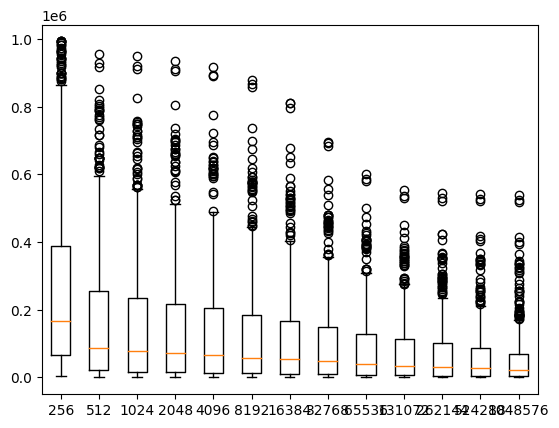

In [13]:
plt.boxplot(data.values(), labels=data.keys())